In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
train_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/train'
test_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/test'
valid_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/val'

In [3]:
batch_size = 16 
img_height = 500
img_width = 500

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Create Image Data Generator for Train Set
image_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # Increased for more variety
    width_shift_range=0.15, 
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Create Image Data Generator for Test/Validation Set
test_data_gen = ImageDataGenerator(rescale = 1./255)

In [5]:
train = image_gen.flow_from_directory(
    train_path,
    target_size=(500, 500),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=16
)

# Important: Keep shuffle=False for test to get a proper confusion matrix later
test = test_data_gen.flow_from_directory(
    test_path,
    target_size=(500, 500),
    color_mode='grayscale',
    shuffle=False, 
    class_mode='binary',
    batch_size=16
)

valid = test_data_gen.flow_from_directory(
    valid_path,
    target_size=(500, 500),
    color_mode='grayscale',
    class_mode='binary', 
    batch_size=16
)

Found 2939 images belonging to 2 classes.
Found 421 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [8]:
# 2. PROPOSED ARCHITECTURE
# Adding BatchNormalization for stability and Dropout to prevent bias toward the majority class

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
model = Sequential()

# Block 1
model.add(Input(shape=(img_width, img_height, 1)))
model.add(Conv2D(32, (3, 3), activation="relu", padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(64, (3, 3), activation="relu", padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(128, (3, 3), activation="relu", padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model.add(Conv2D(128, (3, 3), activation="relu", padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # High dropout helps the model generalize TB features
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [9]:
# 3. COMPILATION
# Using a slightly lower learning rate can help when using class weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Restore best weights is the most important addition here
early = EarlyStopping(
    monitor="val_loss", 
    mode="min", 
    patience=10, 
    restore_best_weights=True
)

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss', 
    patience=5, 
    verbose=1, 
    factor=0.2, 
    min_lr=0.000001
)

callbacks_list = [early, learning_rate_reduction]


In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train.classes),
    y=train.classes
)

cw = dict(zip(np.unique(train.classes), weights))
print(cw)

{0: 0.5997959183673469, 1: 3.005112474437628}


In [12]:
# 4. TRAINING WITH YOUR EXISTING WEIGHTS
# Use the 'cw' class weights you already calculated
model.fit(
    train,
    validation_data=valid,
    epochs=100, # EarlyStopping will stop it earlier if needed
    class_weight=cw,
    callbacks=callbacks_list
)


Epoch 1/100


2026-04-01 11:37:26.797965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-01 11:37:26.856163: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


184/184 [==============================] - 77s 390ms/step - loss: 6.5719 - accuracy: 0.7683 - recall: 0.7178 - precision: 0.3926 - val_loss: 7.8963 - val_accuracy: 0.1833 - val_recall: 0.9857 - val_precision: 0.1679 - lr: 1.0000e-04
Epoch 2/100
184/184 [==============================] - 74s 404ms/step - loss: 6.4493 - accuracy: 0.8384 - recall: 0.8037 - precision: 0.5091 - val_loss: 13.1928 - val_accuracy: 0.6881 - val_recall: 0.5000 - val_precision: 0.2672 - lr: 1.0000e-04
Epoch 3/100
184/184 [==============================] - 92s 500ms/step - loss: 5.3739 - accuracy: 0.9023 - recall: 0.8978 - precision: 0.6494 - val_loss: 15.2709 - val_accuracy: 0.7964 - val_recall: 0.6143 - val_precision: 0.4236 - lr: 1.0000e-04
Epoch 4/100
184/184 [==============================] - 90s 489ms/step - loss: 5.6422 - accuracy: 0.9071 - recall: 0.9018 - precision: 0.6622 - val_loss: 78.9287 - val_accuracy: 0.8345 - val_recall: 0.0071 - val_precision: 1.0000 - lr: 1.0000e-04
Epoch 5/100
184/184 [========

<Axes: >

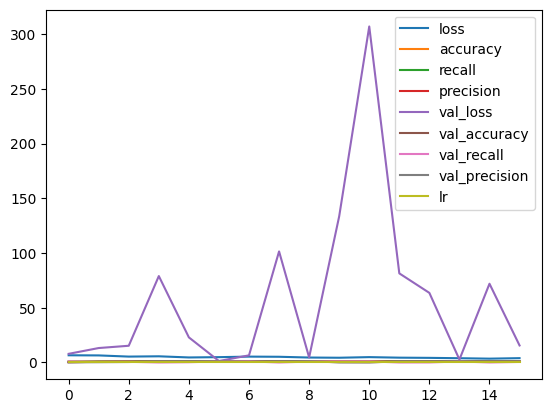

In [15]:
import pandas as pd

pd.DataFrame(model.history.history).plot()

In [16]:
test_accu = model.evaluate(test)
print('The testing accuracy is :',test_accu[1]*100, '%')

27/27 [==============================] - 3s 96ms/step - loss: 0.1821 - accuracy: 0.9952 - recall: 0.9859 - precision: 0.9859
The testing accuracy is : 99.52493906021118 %


In [18]:
preds = model.predict(test,verbose=1)

27/27 [==============================] - 2s 72ms/step


In [19]:
predictions = preds.copy()
predictions[predictions <= 0.5] = 0
predictions[predictions > 0.5] = 1

<Axes: >

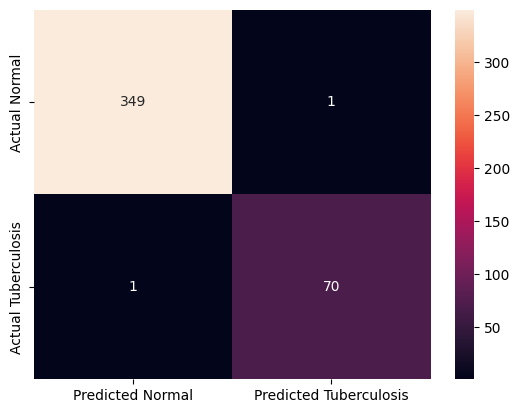

In [20]:
from sklearn.metrics import classification_report,confusion_matrix
cm = pd.DataFrame(data=confusion_matrix(test.classes, predictions, labels=[0, 1]),index=["Actual Normal", "Actual Tuberculosis"],
columns=["Predicted Normal", "Predicted Tuberculosis"])

import seaborn as sns
sns.heatmap(cm,annot=True,fmt="d")

In [21]:
print(classification_report(y_true=test.classes,y_pred=predictions,target_names =['NORMAL','TUBERCULOSIS']))

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00       350
TUBERCULOSIS       0.99      0.99      0.99        71

    accuracy                           1.00       421
   macro avg       0.99      0.99      0.99       421
weighted avg       1.00      1.00      1.00       421



(421, 500, 500, 1)
(421,)


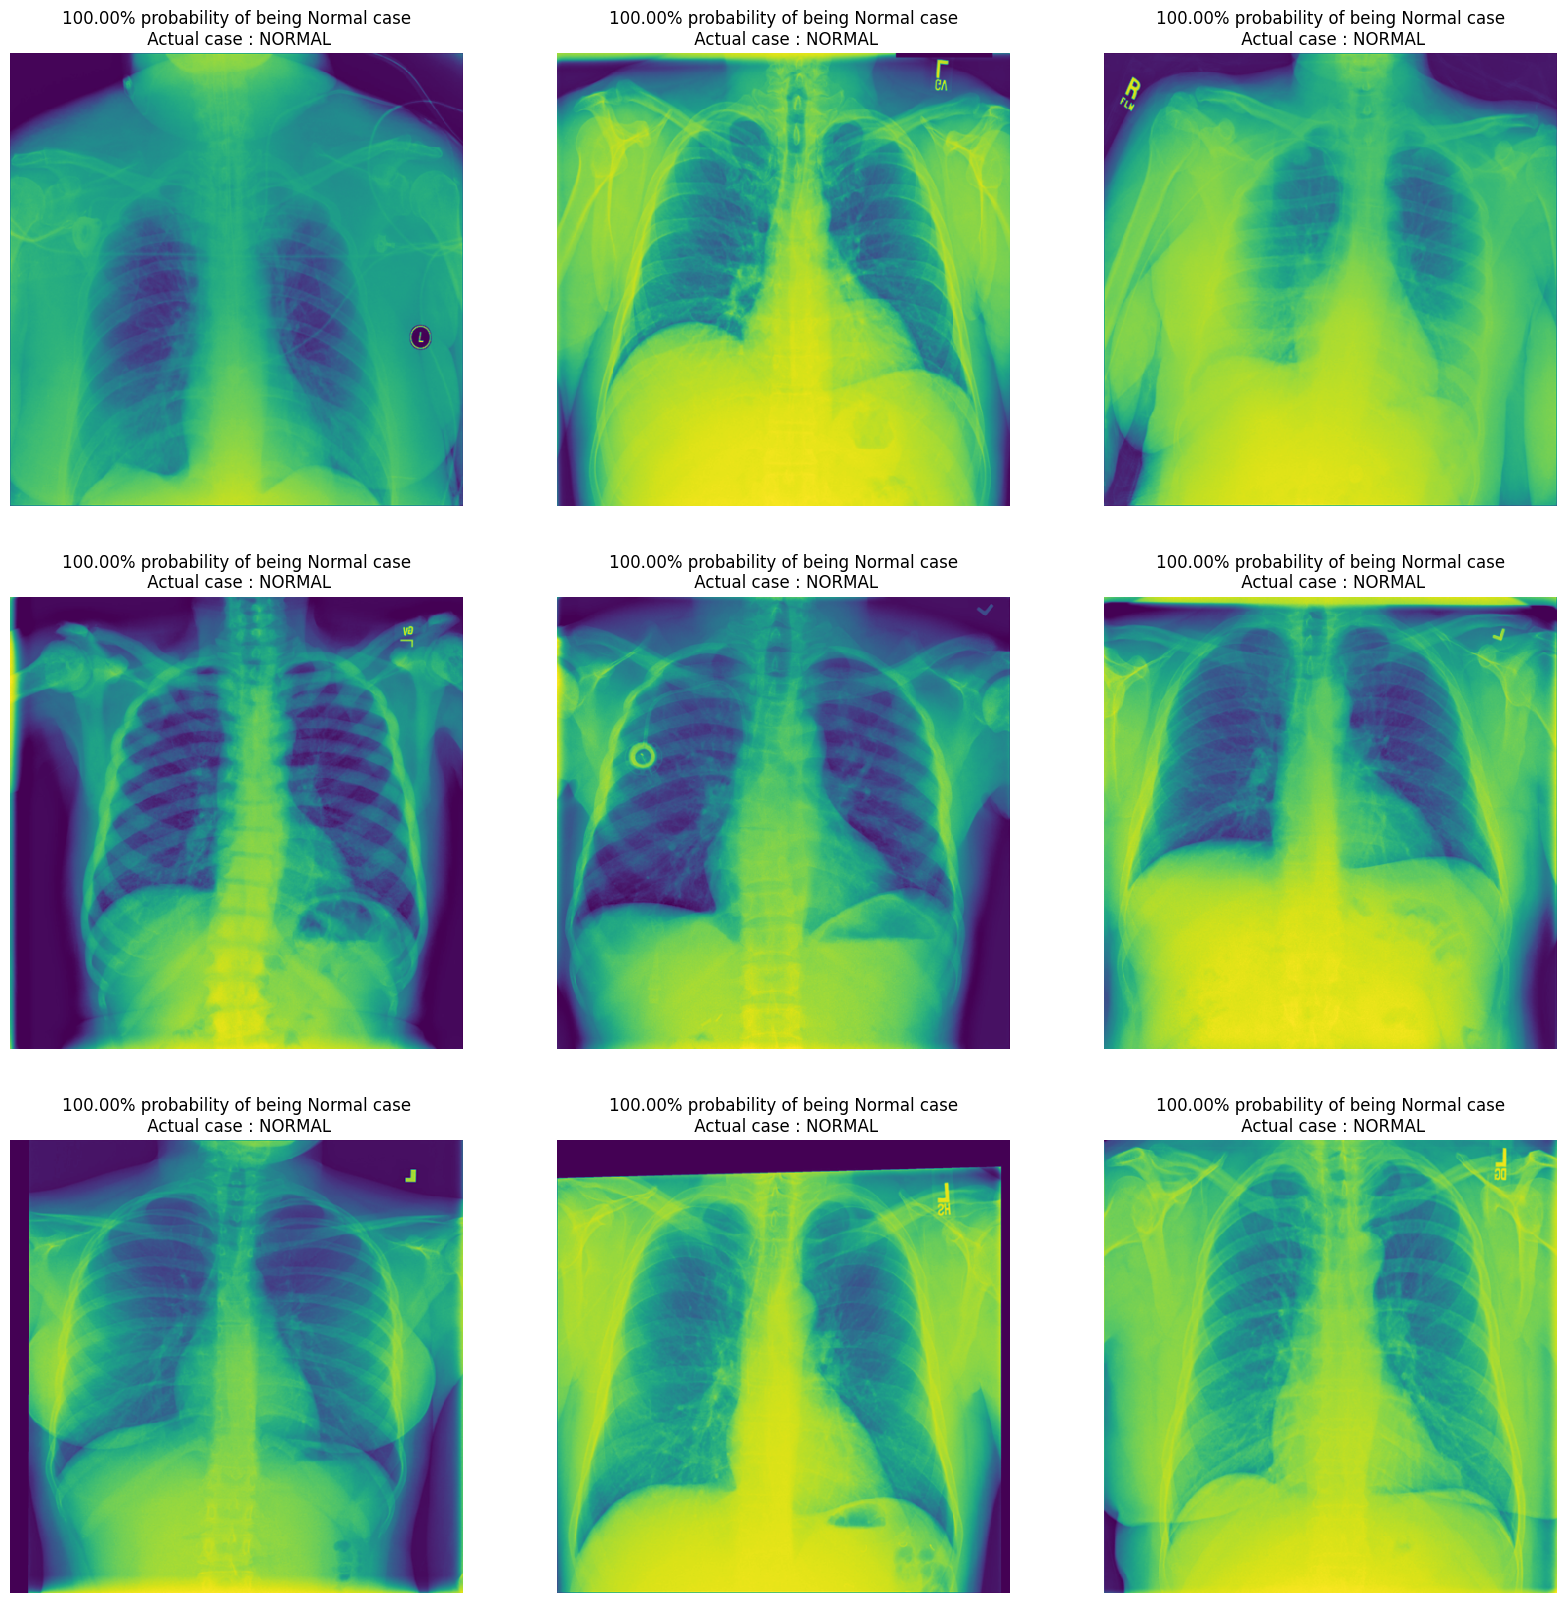

In [23]:
import numpy as np 
import matplotlib.pyplot as plt 

test.reset()
x=np.concatenate([test.next()[0] for i in range(test.__len__())])
y=np.concatenate([test.next()[1] for i in range(test.__len__())])
print(x.shape)
print(y.shape)
#this little code above extracts the images from test Data iterator without shuffling the sequence
# x contains image array and y has labels 
dic = {0:'NORMAL', 1:'TUBERCULOSIS'}
plt.figure(figsize=(20,20))
for i in range(0+228, 9+228):
  plt.subplot(3, 3, (i-228)+1)
  if preds[i, 0] >= 0.5: 
    out = ('{:.2%} probability of being Tuberculosis case'.format(preds[i][0]))
      
      
  else: 
    out = ('{:.2%} probability of being Normal case'.format(1-preds[i][0]))
  plt.title(out+"\n Actual case : "+ dic.get(y[i]))    
  plt.imshow(np.squeeze(x[i]))
  plt.axis('off')
plt.show()

In [25]:
model.save(filepath='/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/models/trained/tuberculosis_X_ray_best.keras')